# Categorical Regression



[Click here to run this notebook on Colab](https://colab.research.google.com/github/AllenDowney/SurveyDataPyMC/blob/main/notebooks/02_categorical_regression.ipynb)

In [1]:
%load_ext autoreload
%autoreload 2
%load_ext jupyter_black

In [2]:
# Get utils.py
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/SurveyDataPyMC/raw/main/notebooks/utils.py")

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

from utils import value_counts, decorate

In [4]:
# Make the figures smaller to save some screen real estate
plt.rcParams["figure.dpi"] = 75
plt.rcParams["figure.figsize"] = [6, 3.5]
plt.rcParams["axes.titlelocation"] = "left"

## Data

In [5]:
# This dataset is prepared in GssExtract/notebooks/02_make_extract-2022_4.ipynb
# It has been resampled to correct for stratified sampling

DATA_PATH = "https://github.com/AllenDowney/GssExtract/raw/main/data/interim/"
filename = "gss_extract_2022_4.hdf"
download(DATA_PATH + filename)

In [6]:
gss = pd.read_hdf(filename, "gss")
gss.columns

Index(['age', 'attend', 'ballot', 'class', 'clmtcaus', 'clmtusa', 'clmtwrld',
       'cohort', 'commun', 'conarmy', 'conbus', 'conclerg', 'coneduc',
       'confed', 'confinan', 'coninc', 'conjudge', 'conlabor', 'conlegis',
       'conmedic', 'conpress', 'conrinc', 'consci', 'contv', 'degree', 'educ',
       'eqwlth', 'fair', 'fear', 'fund', 'goodlife', 'hapmar', 'happy',
       'health', 'helpful', 'id', 'life', 'partyid', 'polviews', 'pres16',
       'pres20', 'race', 'realinc', 'realrinc', 'reg16', 'region', 'relig',
       'relig16', 'reliten', 'res16', 'rincome', 'satfin', 'satjob', 'sex',
       'sexbirth', 'sexnow', 'srcbelt', 'trust', 'wtssall', 'year'],
      dtype='object')

> Did you vote for Joe Biden or Donald Trump?

```
1 Biden
2 Trump
3 Other
4 Didn't vote
```

In [7]:
value_counts(gss["pres20"])

,counts
values,
1.0,1259
2.0,946
3.0,96
4.0,16
NaN,70073


In [8]:
gss["y"] = gss["pres20"].replace({3: 0, 4: np.nan})
value_counts(gss["y"])

,counts
values,
0.0,96
1.0,1259
2.0,946
NaN,70089


In [9]:
vote_map = {
    0: "Other",
    1: "Biden",
    2: "Trump",
}

In [10]:
from utils import round_into_bins

gss["age_group"] = round_into_bins(gss["age"].copy(), 5, low=13) + 2

In [11]:
gss["y"]

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
        ... 
72385    2.0
72386    NaN
72387    1.0
72388    NaN
72389    1.0
Name: y, Length: 72390, dtype: float64

In [12]:
table = (
    pd.crosstab(gss["age_group"], gss["y"], normalize="index").rename(columns=vote_map)
    * 100
)

In [13]:
table

y,Other,Biden,Trump
age_group,,,
20,0.680272,61.224490,38.095238
25,9.859155,59.154930,30.985915
30,2.684564,74.496644,22.818792
35,3.816794,59.541985,36.641221
40,5.851064,39.893617,54.255319
45,4.729730,56.418919,38.851351
50,4.149378,48.962656,46.887967
55,5.747126,56.896552,37.356322
60,3.255814,53.953488,42.790698


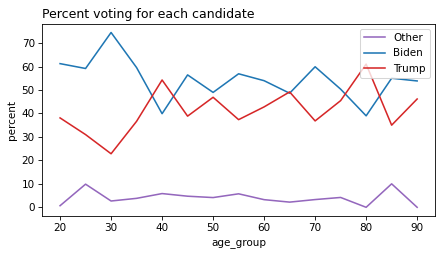

In [14]:
colors = ["C4", "C0", "C3"]
table.plot(color=colors)
decorate(ylabel="percent", title="Percent voting for each candidate")

## Categorical Regression


In [15]:
data = gss.dropna(subset=["y", "age"])
data.shape

(2185, 62)

In [16]:
y = data["y"].values
year = data["year"].values

Shift `year` so it's centered at its mean.

In [17]:
year_shift = data["year"].mean()
year = year - year_shift

Here's the model.

In [18]:
# import pytensor
import pytensor.tensor as pt

y = data["y"].values
age = data["age"].values

# Center age
age_shift = age.mean()
age_centered = age - age_shift

with pm.Model(
    coords={
        "candidate": ["Other", "Biden", "Trump"],
        "obs_idx": np.arange(len(y)),
        "candidate_no_other": ["Biden", "Trump"],
    }
) as categorical_model:
    # Data Features
    age_centered_pt = pm.Data("age_centered", age_centered, dims=["obs_idx"])

    # Data Target
    y_pt = pm.Data("y", y, dims=["obs_idx"])

    # Priors
    alpha = pm.Normal(
        "alpha", 0, 1, shape=2, dims=["candidate_no_other"]
    )  # Biden, Trump (relative to Other)
    beta_age = pm.Normal(
        "beta_age", 0, 1, shape=2, dims=["candidate_no_other"]
    )  # Biden, Trump (relative to Other)

    # Compute logits for each party across all respondents
    logit_other = pt.zeros(age_centered_pt.shape[0])
    logit_biden = alpha[0] + beta_age[0] * age_centered_pt
    logit_trump = alpha[1] + beta_age[1] * age_centered_pt

    # Collect logits in deterministic node
    logits = pm.Deterministic(
        "logits",
        pm.math.stack(
            [logit_other, logit_biden, logit_trump],
            axis=1,
        ),
        dims=["obs_idx", "candidate"],
    )

    # Compute probabilities for each party across all respondents
    p = pm.Deterministic(
        "probabilities", pm.math.softmax(logits, axis=1), dims=["obs_idx", "candidate"]
    )

    # Likelihood:
    y_obs = pm.Categorical("observed_vote_counts", p=p, observed=y_pt, dims=["obs_idx"])

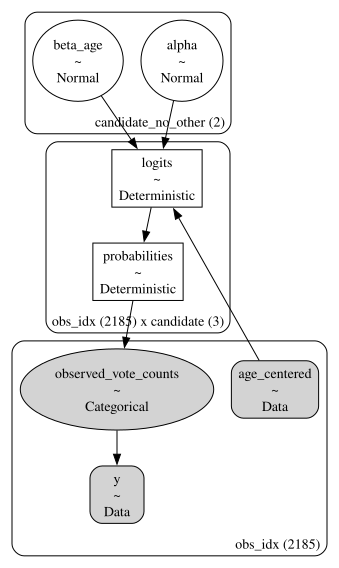

In [19]:
pm.model_to_graphviz(categorical_model)

In [20]:
with categorical_model:
    idata_categorical = pm.sample(500, var_names=["alpha", "beta_age"])

Output()

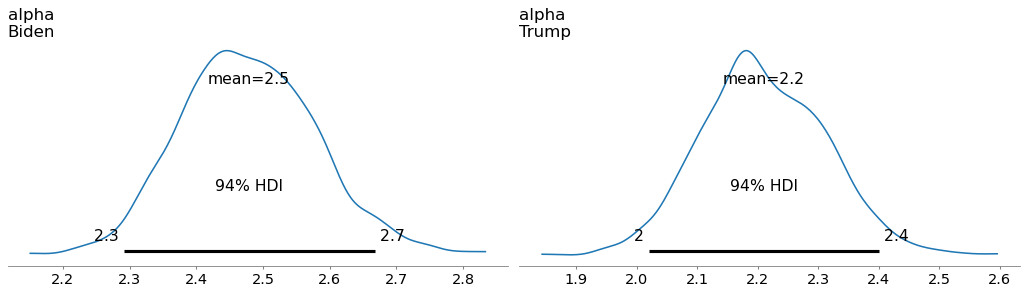

In [21]:
az.plot_posterior(idata_categorical, var_names=["alpha"])
decorate()

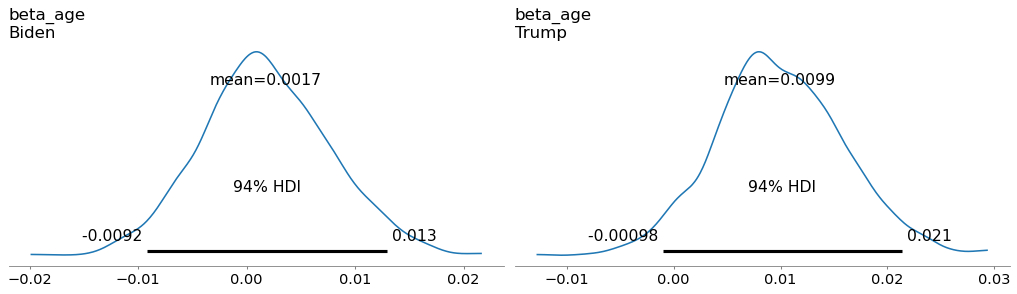

In [22]:
az.plot_posterior(idata_categorical, var_names=["beta_age"])
decorate()

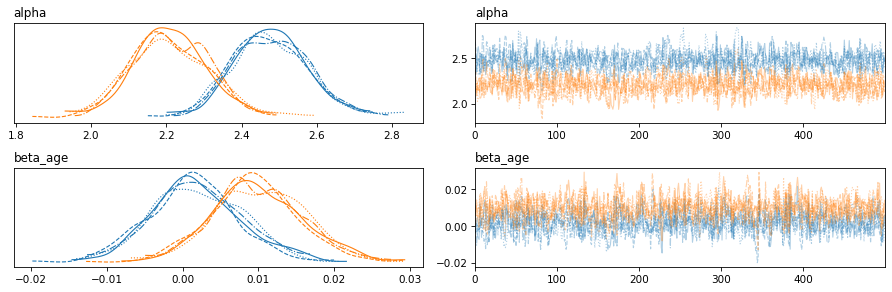

In [23]:
az.plot_trace(idata_categorical)
decorate()

To check these properties numerically, we can look at two key summary statistics: ESS and r-hat.

*    Effective Sample Size (ESS) tells us how much independent information the chains actually contribute. If successive values within a chain are highly correlated, the chain isn’t exploring the posterior efficiently, and ESS will be smaller than the total number of draws.

*    r-hat quantifies the difference between chains. If all chains converged to the same posterior distribution, r-hat should be close to 1. If the chains are exploring different regions, r-hat will be larger than 1, indicating failure to coverge.

In [24]:
az.summary(idata_categorical)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[Biden],2.478,0.102,2.291,2.668,0.003,0.003,992.0,956.0,1.01
alpha[Trump],2.210,0.103,2.021,2.400,0.003,0.003,1023.0,903.0,1.00
beta_age[Biden],0.002,0.006,-0.009,0.013,0.000,0.000,929.0,1000.0,1.00
beta_age[Trump],0.010,0.006,-0.001,0.021,0.000,0.000,1029.0,1059.0,1.00


In [25]:
idata_categorical

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

### Interpreting the results

#### Generating predictions

In [26]:
pred_age_range = np.arange(18, 95)
pred_age_centered = pred_age_range - age_shift
n_pred_ages = len(pred_age_range)

with categorical_model:
    pm.set_data(
        {"age_centered": pred_age_centered}, coords={"obs_idx": np.arange(n_pred_ages)}
    )
    predictions = pm.compute_deterministics(
        idata_categorical.posterior, var_names=["logits", "probabilities"]
    )

Output()

#### Plot 

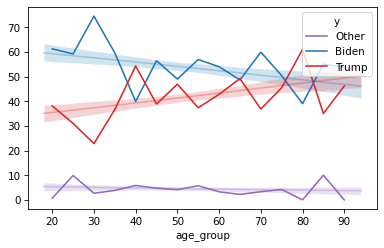

In [27]:
table.plot(color=colors)
for i, name in vote_map.items():
    predictions_tmp = predictions.sel(candidate=name)
    hdis_tmp = az.hdi(predictions_tmp, hdi_prob=0.9)
    predictions_mean = predictions_tmp.mean(dim=["chain", "draw"])

    # plot the mean
    plt.plot(
        pred_age_range,
        predictions_mean["probabilities"].values * 100,
        color=colors[i],
        alpha=0.3,
    )
    plt.fill_between(
        pred_age_range,
        hdis_tmp.sel(hdi="lower")["probabilities"].values * 100,
        hdis_tmp.sel(hdi="higher")["probabilities"].values * 100,
        color=colors[i],
        alpha=0.2,
        lw=0,
    )

## Adding a categorical predictor

In [28]:
value_counts(gss["sex"])

,counts
values,
1.0,33238
2.0,39001
NaN,151


In [29]:
data = gss.dropna(subset=["y", "age", "sex"])
data.shape

(2184, 62)

In [30]:
data

,age,attend,ballot,class,clmtcaus,clmtusa,clmtwrld,cohort,commun,conarmy,...,satjob,sex,sexbirth,sexnow,srcbelt,trust,wtssall,year,y,age_group
68848,40.0,2.0,2.0,3.0,NaN,NaN,NaN,1982.0,NaN,2.0,...,3.0,2.0,NaN,NaN,2.0,2.0,2.398901,2022,2.0,40
68849,49.0,0.0,1.0,3.0,NaN,NaN,NaN,1973.0,NaN,NaN,...,NaN,1.0,NaN,NaN,1.0,NaN,0.723669,2022,2.0,50
68850,46.0,2.0,1.0,3.0,NaN,NaN,NaN,1976.0,NaN,NaN,...,3.0,2.0,NaN,NaN,5.0,NaN,7.592118,2022,1.0,45
68853,21.0,3.0,1.0,3.0,NaN,NaN,NaN,2001.0,NaN,NaN,...,NaN,1.0,NaN,NaN,4.0,NaN,3.030611,2022,1.0,20
68854,49.0,2.0,2.0,3.0,NaN,NaN,NaN,1973.0,NaN,1.0,...,1.0,1.0,NaN,NaN,5.0,NaN,1.608149,2022,2.0,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72381,48.0,2.0,1.0,2.0,NaN,NaN,NaN,1974.0,NaN,NaN,...,NaN,2.0,NaN,NaN,5.0,NaN,0.981892,2022,1.0,50
72383,63.0,3.0,2.0,3.0,NaN,NaN,NaN,1959.0,NaN,2.0,...,NaN,1.0,NaN,NaN,1.0,2.0,2.788905,2022,1.0,65
72385,50.0,2.0,2.0,2.0,NaN,NaN,NaN,1972.0,NaN,1.0,...,1.0,1.0,NaN,NaN,3.0,2.0,5.322235,2022,2.0,50
72387,22.0,6.0,3.0,3.0,NaN,NaN,NaN,2000.0,NaN,2.0,...,3.0,2.0,NaN,NaN,5.0,NaN,2.449262,2022,1.0,20


In [31]:
y = data["y"].values
age = data["age"].values
sex = data["sex"].values  # 1 = male, 2 = female

# Center age
age_shift = age.mean()
age_centered = age - age_shift

# Recode sex to 0 = male, 1 = female
sex = (sex == 2).astype(int)

sex_labeled = data["sex"].apply(lambda x: "male" if x == 1 else "female")

In [32]:
with pm.Model(
    coords={
        "candidate": ["Other", "Biden", "Trump"],
        "obs_idx": np.arange(len(y)),
        "candidate_no_other": ["Biden", "Trump"],
    }
) as categorical_model2:
    # Data Features
    age_centered_pt = pm.Data("age_centered", age_centered, dims=["obs_idx"])
    sex_pt = pm.Data("female_binary", sex, dims=["obs_idx"])

    # Data Target
    y_pt = pm.Data("y", y, dims=["obs_idx"])

    # Priors
    # Biden, Trump (relative to Other)
    alpha = pm.Normal("alpha", 0, 1, dims=["candidate_no_other"])

    # Slopes for age (Biden, Trump)
    beta_age = pm.Normal("beta_age", 0, 1, dims=["candidate_no_other"])

    # Slopes for sex (Biden, Trump)
    beta_female = pm.Normal("beta_female", 0, 1, dims=["candidate_no_other"])

    # Compute logits for each party across all respondents
    logit_other = pt.zeros(age_centered_pt.shape[0])
    logit_biden = alpha[0] + beta_age[0] * age_centered_pt + beta_female[0] * sex_pt
    logit_trump = alpha[1] + beta_age[1] * age_centered_pt + beta_female[1] * sex_pt

    #
    logits = pm.Deterministic(
        "logits",
        pm.math.stack([logit_other, logit_biden, logit_trump], axis=1),
        dims=["obs_idx", "candidate"],
    )

    # Compute probabilities for each party across all respondents
    p = pm.Deterministic(
        "probabilities", pm.math.softmax(logits, axis=1), dims=["obs_idx", "candidate"]
    )

    # Likelihood
    y_obs = pm.Categorical("observed_vote_counts", p=p, observed=y_pt, dims=["obs_idx"])

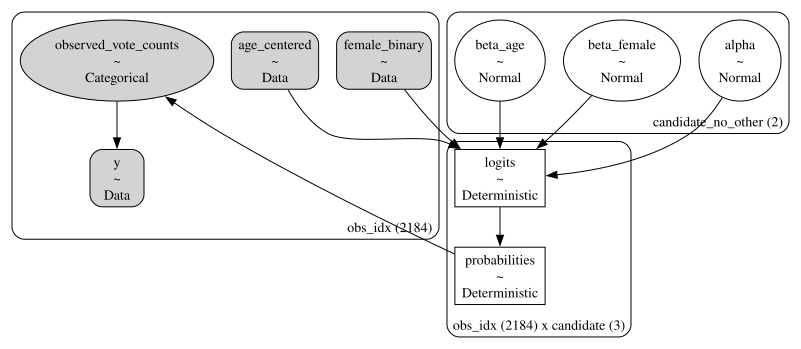

In [33]:
pm.model_to_graphviz(categorical_model2)

In [34]:
with categorical_model2:
    idata_categorical2 = pm.sample(500, var_names=["alpha", "beta_age", "beta_female"])

Output()

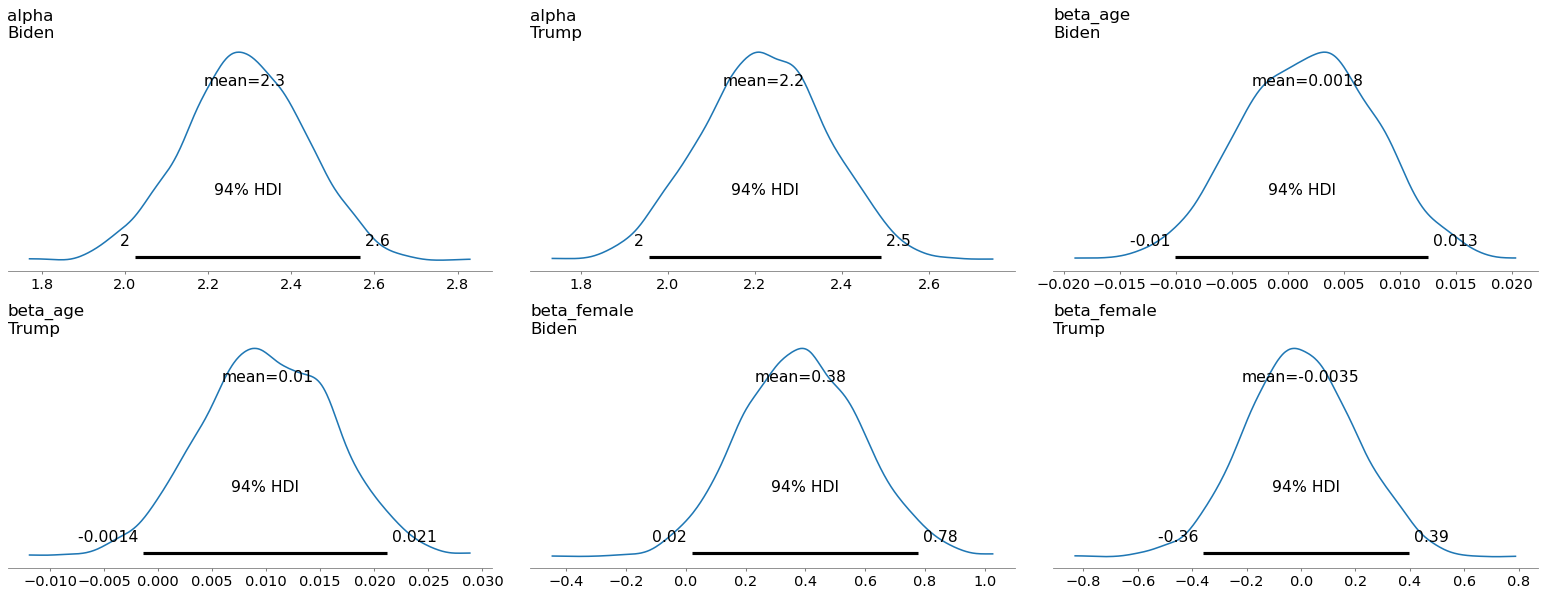

In [35]:
az.plot_posterior(idata_categorical2)
decorate()

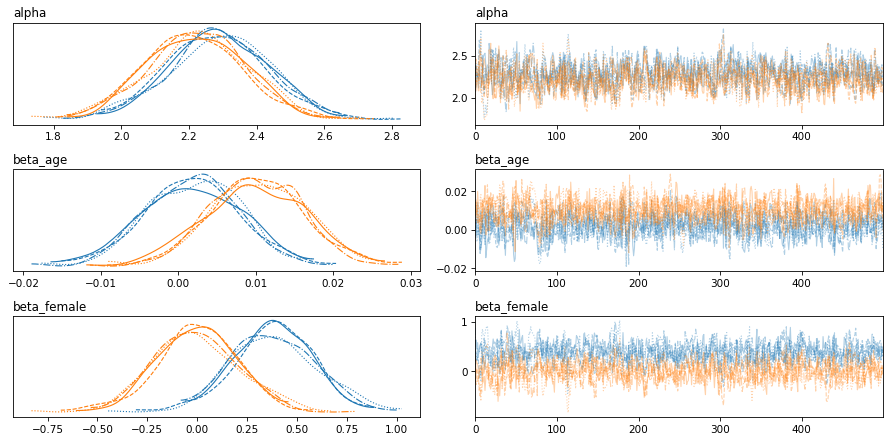

In [36]:
az.plot_trace(idata_categorical2)
decorate()

In [37]:
az.summary(idata_categorical2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha[Biden],2.287,0.145,2.024,2.566,0.005,0.004,776.0,902.0,1.00
alpha[Trump],2.221,0.146,1.958,2.490,0.005,0.004,771.0,901.0,1.00
beta_age[Biden],0.002,0.006,-0.010,0.013,0.000,0.000,1017.0,1150.0,1.00
beta_age[Trump],0.010,0.006,-0.001,0.021,0.000,0.000,983.0,1072.0,1.00
beta_female[Biden],0.384,0.202,0.020,0.777,0.007,0.006,795.0,691.0,1.01
beta_female[Trump],-0.003,0.206,-0.360,0.395,0.007,0.006,806.0,671.0,1.00


### Interpreting the Results

#### Generating Predictions

In [38]:
pred_age_range = np.arange(18, 95)
pred_age_centered = pred_age_range - age_shift
n_pred_ages = len(pred_age_range)

predictions2 = {}
with categorical_model2:
    # Get outputs for males
    pm.set_data(
        {
            "age_centered": pred_age_centered,
            "female_binary": np.zeros(n_pred_ages).astype(int),
        },
        coords={"obs_idx": np.arange(n_pred_ages)},
    )
    predictions2["male"] = pm.compute_deterministics(
        idata_categorical2.posterior, var_names=["logits", "probabilities"]
    )

    # Get outputs for females
    pm.set_data(
        {
            "age_centered": pred_age_centered,
            "female_binary": np.ones(n_pred_ages).astype(int),
        },
        coords={"obs_idx": np.arange(n_pred_ages)},
    )

    predictions2["female"] = pm.compute_deterministics(
        idata_categorical2.posterior, var_names=["logits", "probabilities"]
    )

Output()

Output()

#### Plotting

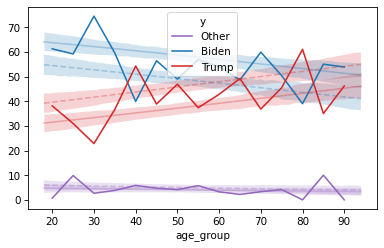

In [39]:
style_dict = {"male": "--", "female": "-"}

table.plot(color=colors)

for sex in predictions2.keys():
    for i, name in vote_map.items():
        predictions_tmp = predictions2[sex].sel(candidate=name)
        hdis_tmp = az.hdi(predictions_tmp, hdi_prob=0.9)
        predictions_mean = predictions_tmp.mean(dim=["chain", "draw"])

        plt.plot(
            pred_age_range,
            predictions_mean["probabilities"].values * 100,
            color=colors[i],
            ls=style_dict[sex],
            alpha=0.3,
        )
        plt.fill_between(
            pred_age_range,
            hdis_tmp.sel(hdi="lower")["probabilities"].values * 100,
            hdis_tmp.sel(hdi="higher")["probabilities"].values * 100,
            color=colors[i],
            ls=style_dict[sex],
            alpha=0.2,
            lw=0,
        )